# Player LTV Prediction Pipeline - Interactive Notebook

This notebook provides an interactive version of the LTV prediction pipeline with inline visualizations and comprehensive model analysis.

## Table of Contents
1. [Setup & Imports](#setup)
2. [Data Loading & Preparation](#data)
3. [Model Training & Evaluation](#models)
4. [Visualizations & Analysis](#viz)
5. [Results Summary](#results)

## 1. Setup & Imports {#setup}

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline plotting
plt.style.use('default')
%matplotlib inline

# Set figure size defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [2]:
# ML libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.linear_model import ElasticNet, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_score, KFold
import joblib
import os

# Advanced ML models - handle import errors gracefully
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    print("⚠ XGBoost not available. Install with: pip install xgboost")
    XGBOOST_AVAILABLE = False

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✓ LightGBM available")
except ImportError:
    print("⚠ LightGBM not available. Install with: pip install lightgbm")
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("✓ CatBoost available")
except ImportError:
    print("⚠ CatBoost not available. Install with: pip install catboost")
    CATBOOST_AVAILABLE = False

✓ XGBoost available
✓ LightGBM available
✓ CatBoost available


In [3]:
# BigQuery setup
try:
    from google.cloud import bigquery
    BIGQUERY_AVAILABLE = True
    print("✓ BigQuery available")
except ImportError:
    print("⚠ BigQuery not available. Will try to load existing datasets.")
    BIGQUERY_AVAILABLE = False

# Configuration
PROJECT_ID = "gc-forecasting-dev"
DATASET = "test_data"
TABLE = "app_data"
FEATURE_DAYS = 4
PREDICTION_DAYS = 30

# Global variables for plotting
PLOT_DATA = []

✓ BigQuery available


## 2. Data Loading & Preparation {#data}

In [4]:
def load_existing_datasets():
    """Load existing processed datasets if they exist"""
    try:
        if (os.path.exists('data/X_train.csv') and 
            os.path.exists('data/X_val.csv') and 
            os.path.exists('data/X_test.csv') and
            os.path.exists('data/y_train.csv') and
            os.path.exists('data/y_val.csv') and
            os.path.exists('data/y_test.csv') and
            os.path.exists('data/feature_columns.pkl')):
            
            print("📁 Found existing processed datasets. Loading...")
            
            # Load processed features
            X_train = pd.read_csv('data/X_train.csv')
            X_val = pd.read_csv('data/X_val.csv') 
            X_test = pd.read_csv('data/X_test.csv')
            
            # Load targets
            y_train = pd.read_csv('data/y_train.csv')['ltv_30_days'].values
            y_val = pd.read_csv('data/y_val.csv')['ltv_30_days'].values
            y_test = pd.read_csv('data/y_test.csv')['ltv_30_days'].values
            
            # Load feature columns
            feature_cols = joblib.load('data/feature_columns.pkl')
            
            # Load raw data if available
            train_data = None
            val_data = None
            test_data = None
            
            if (os.path.exists('data/train_data_raw.csv') and
                os.path.exists('data/val_data_raw.csv') and
                os.path.exists('data/test_data_raw.csv')):
                train_data = pd.read_csv('data/train_data_raw.csv')
                val_data = pd.read_csv('data/val_data_raw.csv')
                test_data = pd.read_csv('data/test_data_raw.csv')
                print("📁 Raw datasets also loaded")
            
            print(f"✅ Loaded existing datasets:")
            print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
            print(f"   X_val: {X_val.shape}, y_val: {y_val.shape}")
            print(f"   X_test: {X_test.shape}, y_test: {y_test.shape}")
            print(f"   Features: {len(feature_cols)}")
            
            return train_data, val_data, test_data, X_train, X_val, X_test, y_train, y_val, y_test, feature_cols
            
    except Exception as e:
        print(f"❌ Error loading existing datasets: {e}")
        print("Will need to create new datasets...")
    
    return None

# Try to load existing datasets
print("🔍 Checking for existing datasets...")
existing_data = load_existing_datasets()

if existing_data is not None:
    train_data, val_data, test_data, X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = existing_data
    print("\n✅ Successfully loaded existing datasets!")
else:
    print("\n⚠ No existing datasets found. You'll need to run the BigQuery data loading process first.")
    print("Please run the full pltv.py script once to generate the datasets.")

🔍 Checking for existing datasets...
📁 Found existing processed datasets. Loading...
📁 Raw datasets also loaded
✅ Loaded existing datasets:
   X_train: (195881, 72), y_train: (195881,)
   X_val: (46795, 72), y_val: (46795,)
   X_test: (26202, 72), y_test: (26202,)
   Features: 72

✅ Successfully loaded existing datasets!


### Dataset Overview

📊 DATASET SUMMARY
Training set: 195,881 users, 72 features
Validation set: 46,795 users, 72 features
Test set: 26,202 users, 72 features

💰 TARGET STATISTICS
Train - Mean: $0.11, Std: $48.50, Spenders: 264 (0.1%)
Val   - Mean: $7.29, Std: $1577.36, Spenders: 96 (0.2%)
Test  - Mean: $4.24, Std: $685.65, Spenders: 13 (0.0%)

🎯 FEATURE OVERVIEW
Total features: 72
First 10 features: ['fingerprinted_events', 'reengagement_events', 'store_browse_ratio', 'active_days', 'weekly_consistency_ratio', 'unique_products_viewed', 'time_diversity_ratio', 'total_sessions', 'evening_activity_ratio', 'partner']


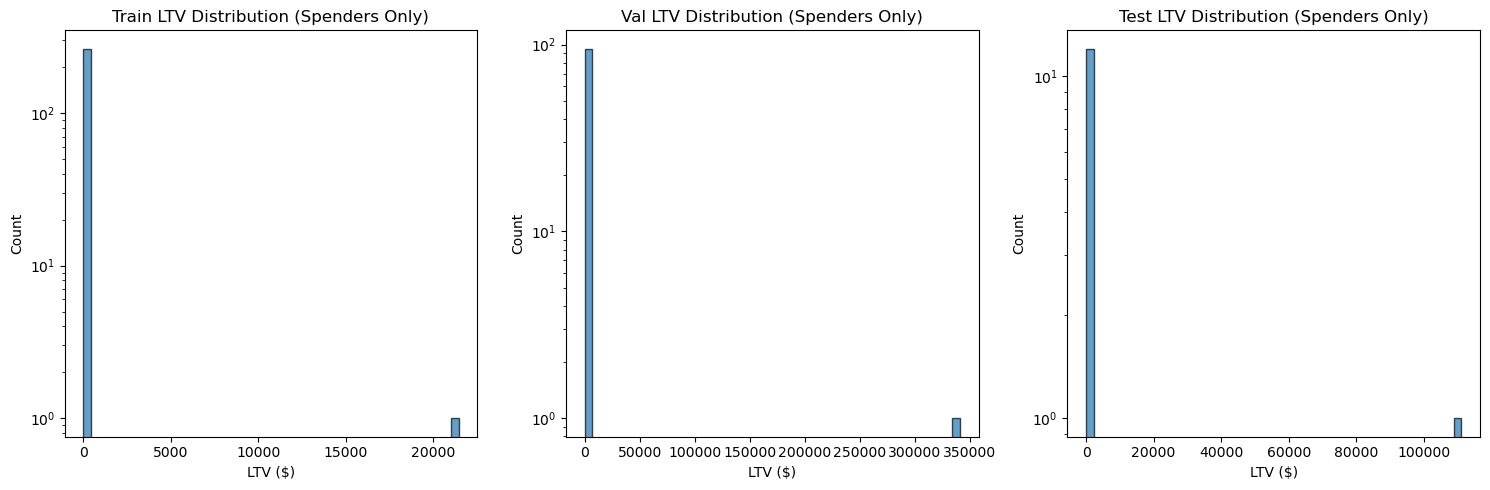

In [5]:
if 'X_train' in locals():
    print("📊 DATASET SUMMARY")
    print("=" * 50)
    print(f"Training set: {X_train.shape[0]:,} users, {X_train.shape[1]} features")
    print(f"Validation set: {X_val.shape[0]:,} users, {X_val.shape[1]} features")
    print(f"Test set: {X_test.shape[0]:,} users, {X_test.shape[1]} features")
    
    print(f"\n💰 TARGET STATISTICS")
    print("=" * 30)
    print(f"Train - Mean: ${y_train.mean():.2f}, Std: ${y_train.std():.2f}, Spenders: {(y_train > 0).sum():,} ({(y_train > 0).mean()*100:.1f}%)")
    print(f"Val   - Mean: ${y_val.mean():.2f}, Std: ${y_val.std():.2f}, Spenders: {(y_val > 0).sum():,} ({(y_val > 0).mean()*100:.1f}%)")
    print(f"Test  - Mean: ${y_test.mean():.2f}, Std: ${y_test.std():.2f}, Spenders: {(y_test > 0).sum():,} ({(y_test > 0).mean()*100:.1f}%)")
    
    # Feature overview
    print(f"\n🎯 FEATURE OVERVIEW")
    print("=" * 30)
    print(f"Total features: {len(feature_cols)}")
    print(f"First 10 features: {feature_cols[:10]}")
    
    # Distribution plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # LTV distributions
    for i, (data, label) in enumerate([(y_train, 'Train'), (y_val, 'Val'), (y_test, 'Test')]):
        spending_users = data[data > 0]
        if len(spending_users) > 0:
            axes[i].hist(spending_users, bins=50, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{label} LTV Distribution (Spenders Only)')
            axes[i].set_xlabel('LTV ($)')
            axes[i].set_ylabel('Count')
            axes[i].set_yscale('log')
        else:
            axes[i].text(0.5, 0.5, 'No spenders', ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} LTV Distribution')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No datasets loaded. Please ensure data files exist or run data loading first.")

## 3. Model Training & Evaluation {#models}

In [6]:
def create_model_configs():
    """Create configuration for all available models"""
    configs = {}
    
    # Always available models
    configs.update({
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        'Extra Trees': ExtraTreesRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42
        ),
        'AdaBoost': AdaBoostRegressor(
            n_estimators=100,
            learning_rate=1.0,
            random_state=42
        ),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=1.0),
        'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5),
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42)
    })
    
    # Add advanced models if available
    if XGBOOST_AVAILABLE:
        configs['XGBoost'] = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='rmse'
        )
    
    if LIGHTGBM_AVAILABLE:
        configs['LightGBM'] = lgb.LGBMRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        )
    
    if CATBOOST_AVAILABLE:
        configs['CatBoost'] = CatBoostRegressor(
            iterations=200,
            depth=6,
            learning_rate=0.1,
            random_seed=42,
            verbose=False
        )
    
    return configs

# Create model configurations
model_configs = create_model_configs()
print(f"🤖 Available models: {len(model_configs)}")
for name in model_configs.keys():
    print(f"  • {name}")

🤖 Available models: 12
  • Random Forest
  • Extra Trees
  • Gradient Boosting
  • AdaBoost
  • Ridge Regression
  • Lasso Regression
  • Elastic Net
  • Linear Regression
  • Decision Tree
  • XGBoost
  • LightGBM
  • CatBoost


In [7]:
def train_all_models(X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, model_configs):
    """Train all models and return results"""
    global PLOT_DATA
    PLOT_DATA.clear()
    
    # Feature scaling
    print("🔧 Scaling features using RobustScaler...")
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    models = {}
    predictions = {}
    results = []
    
    print(f"\n🚀 Training {len(model_configs)} different models...")
    print("=" * 70)
    
    for name, model in model_configs.items():
        print(f"\n--- Training {name} ---")
        try:
            # Use scaled data for linear models
            use_scaled = name in ['Ridge Regression', 'Lasso Regression', 'Elastic Net', 'Linear Regression']
            
            if use_scaled:
                X_tr, X_v, X_te = X_train_scaled, X_val_scaled, X_test_scaled
            else:
                X_tr, X_v, X_te = X_train, X_val, X_test
            
            # Train model
            model.fit(X_tr, y_train)
            
            # Make predictions
            train_pred = model.predict(X_tr)
            val_pred = model.predict(X_v)
            test_pred = model.predict(X_te)
            
            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
            train_mae = mean_absolute_error(y_train, train_pred)
            train_r2 = r2_score(y_train, train_pred)
            
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
            val_mae = mean_absolute_error(y_val, val_pred)
            val_r2 = r2_score(y_val, val_pred)
            
            test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
            test_mae = mean_absolute_error(y_test, test_pred)
            test_r2 = r2_score(y_test, test_pred)
            
            # Store results
            results.append({
                'Model': name,
                'Train_RMSE': train_rmse,
                'Train_MAE': train_mae,
                'Train_R2': train_r2,
                'Val_RMSE': val_rmse,
                'Val_MAE': val_mae,
                'Val_R2': val_r2,
                'Test_RMSE': test_rmse,
                'Test_MAE': test_mae,
                'Test_R2': test_r2
            })
            
            # Store model and predictions
            models[name] = model
            predictions[name] = {
                'train': train_pred,
                'val': val_pred,
                'test': test_pred
            }
            
            # Get feature importance if available
            feature_importance = None
            if hasattr(model, 'feature_importances_'):
                feature_importance = {
                    'importance': model.feature_importances_,
                    'feature_names': feature_cols
                }
            elif hasattr(model, 'coef_'):
                feature_importance = {
                    'importance': np.abs(model.coef_),
                    'feature_names': feature_cols
                }
            
            # Store plot data
            PLOT_DATA.append({
                'model_name': name,
                'y_true': y_test,
                'y_pred': test_pred,
                'feature_importance': feature_importance
            })
            
            print(f"   ✅ Train RMSE: ${train_rmse:.2f}, Val RMSE: ${val_rmse:.2f}, Test RMSE: ${test_rmse:.2f}")
            print(f"      Train R²: {train_r2:.3f}, Val R²: {val_r2:.3f}, Test R²: {test_r2:.3f}")
            
        except Exception as e:
            print(f"   ❌ Error training {name}: {str(e)}")
            continue
    
    return models, predictions, results, scaler

# Train all models
if 'X_train' in locals():
    models, predictions, results, scaler = train_all_models(
        X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, model_configs
    )
    print("\n🎉 Model training completed!")
else:
    print("❌ Cannot train models without datasets. Please load data first.")

🔧 Scaling features using RobustScaler...

🚀 Training 12 different models...

--- Training Random Forest ---
   ✅ Train RMSE: $15.66, Val RMSE: $1509.94, Test RMSE: $595.50
      Train R²: 0.896, Val R²: 0.084, Test R²: 0.246

--- Training Extra Trees ---
   ✅ Train RMSE: $0.11, Val RMSE: $1478.17, Test RMSE: $553.07
      Train R²: 1.000, Val R²: 0.122, Test R²: 0.349

--- Training Gradient Boosting ---
   ✅ Train RMSE: $0.10, Val RMSE: $1478.16, Test RMSE: $553.07
      Train R²: 1.000, Val R²: 0.122, Test R²: 0.349

--- Training AdaBoost ---
   ✅ Train RMSE: $5.02, Val RMSE: $1478.16, Test RMSE: $553.09
      Train R²: 0.989, Val R²: 0.122, Test R²: 0.349

--- Training Ridge Regression ---
   ✅ Train RMSE: $1.17, Val RMSE: $1261.21, Test RMSE: $374.35
      Train R²: 0.999, Val R²: 0.361, Test R²: 0.702

--- Training Lasso Regression ---
   ✅ Train RMSE: $4.38, Val RMSE: $1114.26, Test RMSE: $128.32
      Train R²: 0.992, Val R²: 0.501, Test R²: 0.965

--- Training Elastic Net ---
  

### Model Performance Comparison

In [8]:
if 'results' in locals() and len(results) > 0:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(results)
    comparison_df = comparison_df.sort_values('Val_RMSE').reset_index(drop=True)
    
    print("🏆 MODEL PERFORMANCE COMPARISON")
    print("=" * 80)
    display(comparison_df.round(3))
    
    # Create ensemble from top 3 models
    top_3_models = comparison_df.head(3)['Model'].tolist()
    if len(top_3_models) >= 3:
        ensemble_pred_test = np.mean([predictions[model]['test'] for model in top_3_models], axis=0)
        ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred_test))
        ensemble_r2 = r2_score(y_test, ensemble_pred_test)
        
        # Add ensemble to plot data
        PLOT_DATA.append({
            'model_name': 'Ensemble (Top 3)',
            'y_true': y_test,
            'y_pred': ensemble_pred_test,
            'feature_importance': None
        })
        
        print(f"\n🎯 ENSEMBLE MODEL (Top 3 Average)")
        print(f"   Models used: {', '.join(top_3_models)}")
        print(f"   Test RMSE: ${ensemble_rmse:.2f}, Test R²: {ensemble_r2:.3f}")
else:
    print("❌ No model results available")

🏆 MODEL PERFORMANCE COMPARISON


,Model,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2
0,Lasso Regression,4.384,0.167,0.992,1114.261,5.421,0.501,128.318,0.923,0.965
1,Elastic Net,13.560,1.166,0.922,1220.970,6.831,0.401,68.853,1.290,0.990
2,Ridge Regression,1.175,0.048,0.999,1261.205,5.995,0.361,374.348,2.365,0.702
3,Linear Regression,0.402,0.006,1.000,1317.014,6.150,0.303,271.369,1.680,0.843
4,Decision Tree,0.105,0.001,1.000,1478.154,6.835,0.122,553.069,3.419,0.349
5,Gradient Boosting,0.097,0.001,1.000,1478.161,6.858,0.122,553.072,3.421,0.349
6,AdaBoost,5.015,2.774,0.989,1478.162,9.328,0.122,553.093,6.325,0.349
7,Extra Trees,0.111,0.001,1.000,1478.167,6.871,0.122,553.069,3.420,0.349
8,XGBoost,0.095,0.002,1.000,1478.178,6.838,0.122,553.101,3.420,0.349
9,CatBoost,0.498,0.005,1.000,1492.033,6.923,0.105,598.825,3.709,0.237



🎯 ENSEMBLE MODEL (Top 3 Average)
   Models used: Lasso Regression, Elastic Net, Ridge Regression
   Test RMSE: $104.96, Test R²: 0.977


## 4. Visualizations & Analysis {#viz}

### Performance Overview

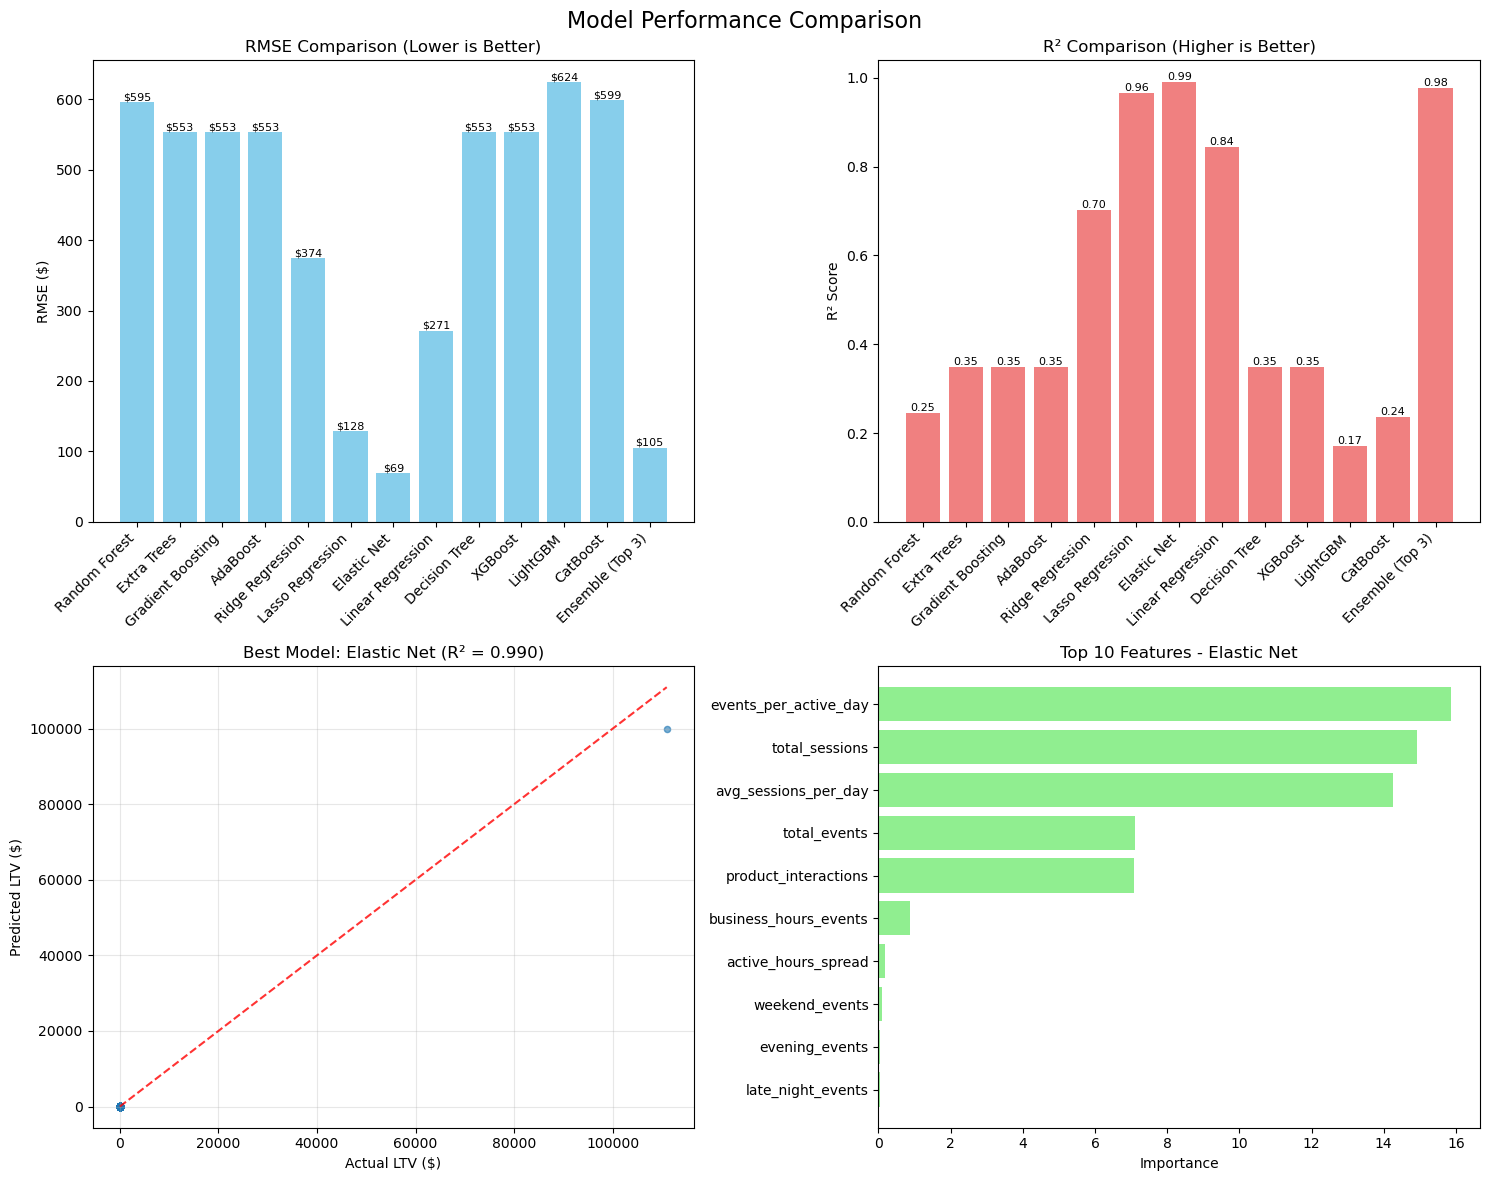

In [9]:
if len(PLOT_DATA) > 0:
    # Model comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16)
    
    # Collect metrics for all models
    model_names = [data['model_name'] for data in PLOT_DATA]
    rmse_values = []
    r2_values = []
    mae_values = []
    
    for data in PLOT_DATA:
        y_true = data['y_true']
        y_pred = data['y_pred']
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        
        rmse_values.append(rmse)
        r2_values.append(r2)
        mae_values.append(mae)
    
    # Plot 1: RMSE comparison
    bars1 = axes[0,0].bar(range(len(model_names)), rmse_values, color='skyblue')
    axes[0,0].set_xticks(range(len(model_names)))
    axes[0,0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0,0].set_title('RMSE Comparison (Lower is Better)')
    axes[0,0].set_ylabel('RMSE ($)')
    
    # Add value labels on bars
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                      f'${height:.0f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: R² comparison
    bars2 = axes[0,1].bar(range(len(model_names)), r2_values, color='lightcoral')
    axes[0,1].set_xticks(range(len(model_names)))
    axes[0,1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0,1].set_title('R² Comparison (Higher is Better)')
    axes[0,1].set_ylabel('R² Score')
    
    # Add value labels on bars
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 3: Actual vs Predicted for best model
    best_idx = np.argmax(r2_values)
    best_data = PLOT_DATA[best_idx]
    y_true = best_data['y_true']
    y_pred = best_data['y_pred']
    
    axes[1,0].scatter(y_true, y_pred, alpha=0.6, s=20)
    max_val = max(y_true.max(), y_pred.max())
    axes[1,0].plot([0, max_val], [0, max_val], 'r--', alpha=0.8)
    axes[1,0].set_xlabel('Actual LTV ($)')
    axes[1,0].set_ylabel('Predicted LTV ($)')
    axes[1,0].set_title(f'Best Model: {best_data["model_name"]} (R² = {r2_values[best_idx]:.3f})')
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 4: Feature importance for best model
    if best_data['feature_importance'] is not None:
        importance = best_data['feature_importance']['importance']
        feature_names = best_data['feature_importance']['feature_names']
        top_indices = np.argsort(importance)[-10:]
        
        axes[1,1].barh(range(10), importance[top_indices], color='lightgreen')
        axes[1,1].set_yticks(range(10))
        axes[1,1].set_yticklabels([feature_names[i] for i in top_indices])
        axes[1,1].set_title(f'Top 10 Features - {best_data["model_name"]}')
        axes[1,1].set_xlabel('Importance')
    else:
        axes[1,1].text(0.5, 0.5, 'No feature importance available', 
                      ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Feature Importance')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No plot data available")

### ROC & Precision-Recall Curves

📈 Calculating ROC and PR curves for LTV prediction (binary: LTV > 0)...
  Random Forest: ROC-AUC = 0.761, PR-AUC = 0.081, Precision@0.9Recall = 0.001
  Extra Trees: ROC-AUC = 0.773, PR-AUC = 0.079, Precision@0.9Recall = 0.001
  Gradient Boosting: ROC-AUC = 0.583, PR-AUC = 0.082, Precision@0.9Recall = 0.000
  AdaBoost: ROC-AUC = 0.513, PR-AUC = 0.077, Precision@0.9Recall = 0.000
  Ridge Regression: ROC-AUC = 0.441, PR-AUC = 0.077, Precision@0.9Recall = 0.000
  Lasso Regression: ROC-AUC = 0.525, PR-AUC = 0.082, Precision@0.9Recall = 0.000
  Elastic Net: ROC-AUC = 0.607, PR-AUC = 0.086, Precision@0.9Recall = 0.000
  Linear Regression: ROC-AUC = 0.505, PR-AUC = 0.078, Precision@0.9Recall = 0.000
  Decision Tree: ROC-AUC = 0.612, PR-AUC = 0.082, Precision@0.9Recall = 0.000
  XGBoost: ROC-AUC = 0.712, PR-AUC = 0.081, Precision@0.9Recall = 0.000
  LightGBM: ROC-AUC = 0.618, PR-AUC = 0.079, Precision@0.9Recall = 0.000
  CatBoost: ROC-AUC = 0.649, PR-AUC = 0.155, Precision@0.9Recall = 0.000
  E

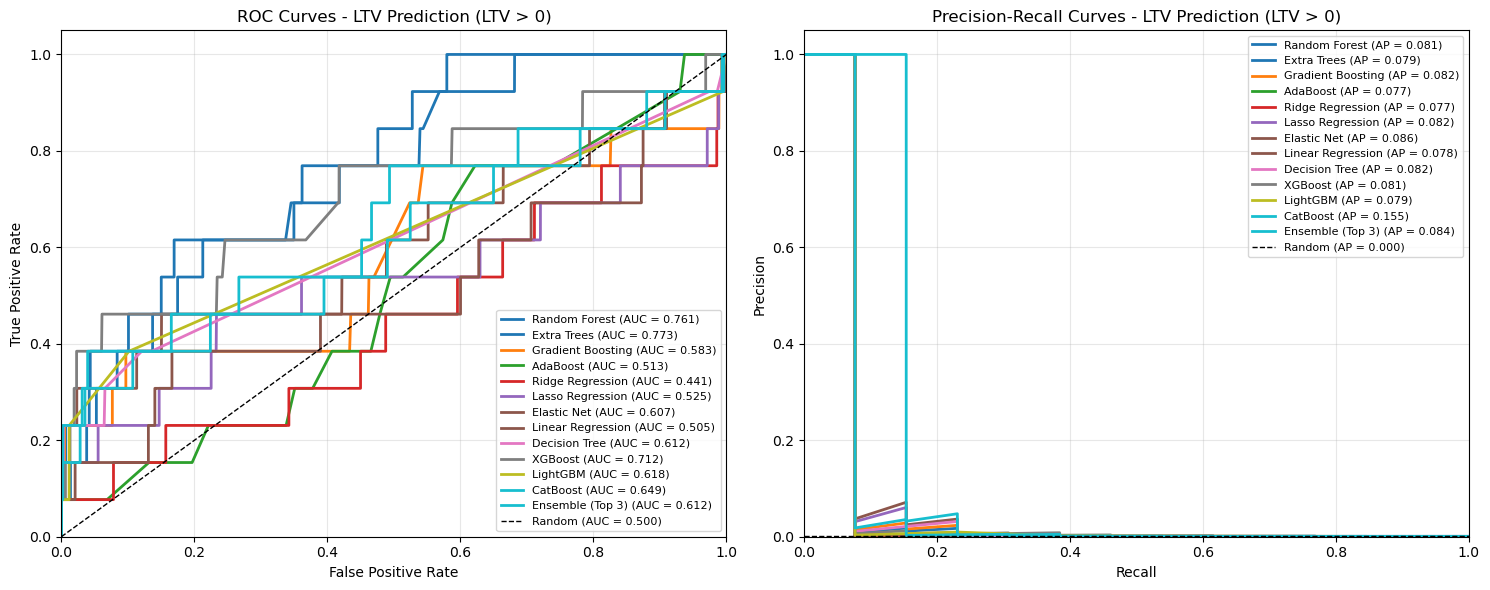


🎯 LTV > 0 DETECTION PERFORMANCE SUMMARY


,Model,ROC_AUC,PR_AUC,Precision_at_90_Recall
1,Extra Trees,0.773,0.079,0.001
0,Random Forest,0.761,0.081,0.001
9,XGBoost,0.712,0.081,0.000
11,CatBoost,0.649,0.155,0.000
10,LightGBM,0.618,0.079,0.000
8,Decision Tree,0.612,0.082,0.000
12,Ensemble (Top 3),0.612,0.084,0.000
6,Elastic Net,0.607,0.086,0.000
2,Gradient Boosting,0.583,0.082,0.000
5,Lasso Regression,0.525,0.082,0.000


In [10]:
if len(PLOT_DATA) > 0:
    # Create ROC and Precision-Recall curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(PLOT_DATA)))
    
    print("📈 Calculating ROC and PR curves for LTV prediction (binary: LTV > 0)...")
    
    roc_results = []
    pr_results = []
    
    for i, data in enumerate(PLOT_DATA):
        model_name = data['model_name']
        y_true = data['y_true']
        y_pred = data['y_pred']
        
        # Convert to binary classification (LTV > 0 vs LTV = 0)
        y_true_binary = (y_true > 0).astype(int)
        y_scores = y_pred
        
        try:
            # ROC Curve
            fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
            roc_auc = auc(fpr, tpr)
            
            # Precision-Recall Curve
            precision, recall, thresholds = precision_recall_curve(y_true_binary, y_scores)
            pr_auc = average_precision_score(y_true_binary, y_scores)
            
            # Find precision at 0.9 recall
            precision_at_90_recall = "N/A"
            if len(recall) > 1:
                recall_diff = np.abs(recall - 0.9)
                closest_idx = np.argmin(recall_diff)
                if recall[closest_idx] >= 0.85:
                    precision_at_90_recall = f"{precision[closest_idx]:.3f}"
            
            # Store results
            roc_results.append({
                'model': model_name,
                'roc_auc': roc_auc,
                'precision_at_90_recall': precision_at_90_recall
            })
            
            pr_results.append({
                'model': model_name,
                'pr_auc': pr_auc
            })
            
            # Plot ROC curve
            ax1.plot(fpr, tpr, color=colors[i], linewidth=2, 
                    label=f'{model_name} (AUC = {roc_auc:.3f})')
            
            # Plot PR curve
            ax2.plot(recall, precision, color=colors[i], linewidth=2,
                    label=f'{model_name} (AP = {pr_auc:.3f})')
            
            print(f"  {model_name}: ROC-AUC = {roc_auc:.3f}, PR-AUC = {pr_auc:.3f}, Precision@0.9Recall = {precision_at_90_recall}")
            
        except Exception as e:
            print(f"  ❌ Error calculating curves for {model_name}: {e}")
            continue
    
    # Format ROC plot
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curves - LTV Prediction (LTV > 0)')
    ax1.legend(loc="lower right", fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Format PR plot
    if len(PLOT_DATA) > 0:
        first_y_true = PLOT_DATA[0]['y_true']
        y_true_binary_baseline = (first_y_true > 0).astype(int)
        baseline_precision = np.sum(y_true_binary_baseline) / len(y_true_binary_baseline)
        ax2.axhline(y=baseline_precision, color='k', linestyle='--', linewidth=1,
                    label=f'Random (AP = {baseline_precision:.3f})')
    
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curves - LTV Prediction (LTV > 0)')
    ax2.legend(loc="upper right", fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create summary table
    summary_data = []
    for roc_res, pr_res in zip(roc_results, pr_results):
        summary_data.append({
            'Model': roc_res['model'],
            'ROC_AUC': roc_res['roc_auc'],
            'PR_AUC': pr_res['pr_auc'],
            'Precision_at_90_Recall': roc_res['precision_at_90_recall']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('ROC_AUC', ascending=False)
    
    print(f"\n🎯 LTV > 0 DETECTION PERFORMANCE SUMMARY")
    print("=" * 60)
    display(summary_df.round(3))
    
else:
    print("❌ No plot data available for ROC/PR curves")

### Individual Model Analysis

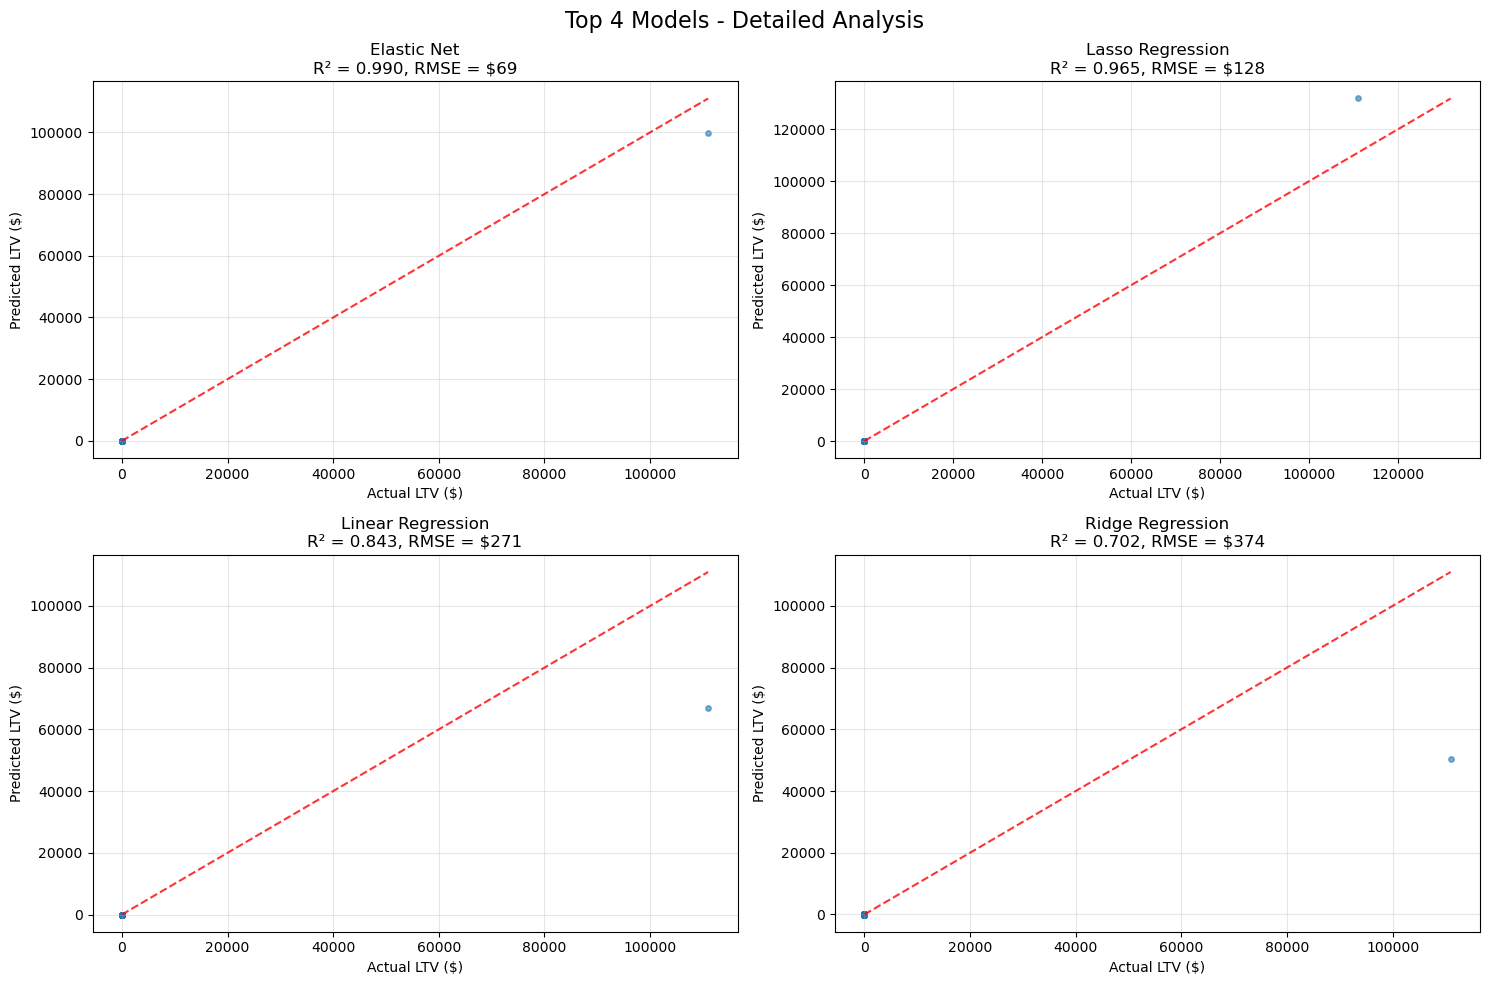

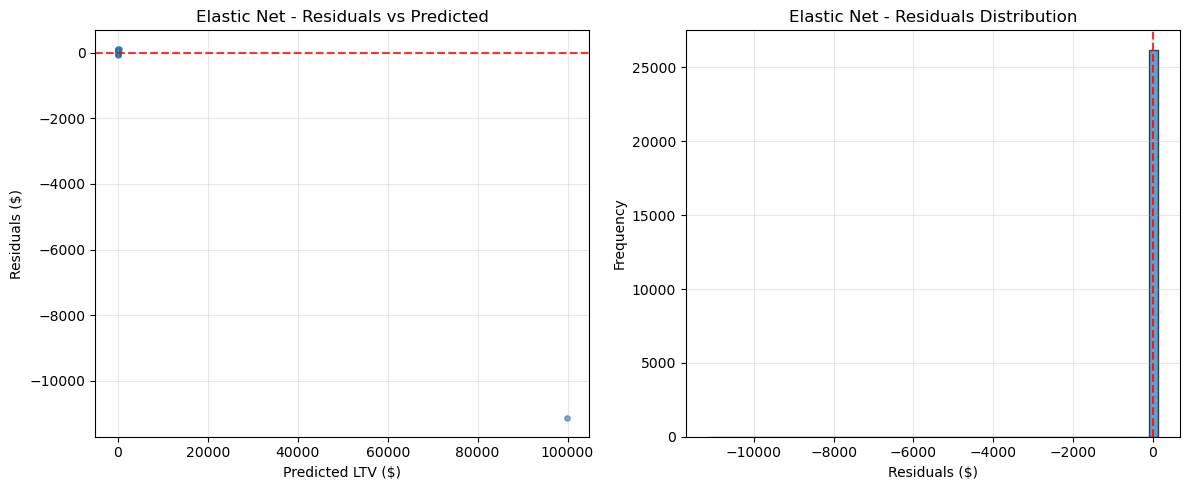

In [11]:
if len(PLOT_DATA) > 3:  # Show top 4 models
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Top 4 Models - Detailed Analysis', fontsize=16)
    
    # Sort by R2 score and take top 4
    plot_data_sorted = sorted(PLOT_DATA[:-1], key=lambda x: r2_score(x['y_true'], x['y_pred']), reverse=True)[:4]
    
    for idx, data in enumerate(plot_data_sorted):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]
        
        y_true = data['y_true']
        y_pred = data['y_pred']
        model_name = data['model_name']
        
        # Scatter plot with perfect prediction line
        ax.scatter(y_true, y_pred, alpha=0.6, s=15)
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.8)
        
        # Calculate metrics
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        
        ax.set_xlabel('Actual LTV ($)')
        ax.set_ylabel('Predicted LTV ($)')
        ax.set_title(f'{model_name}\nR² = {r2:.3f}, RMSE = ${rmse:.0f}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show residuals plot for best model
    best_model_data = plot_data_sorted[0]
    y_true = best_model_data['y_true']
    y_pred = best_model_data['y_pred']
    residuals = y_pred - y_true
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_pred, residuals, alpha=0.6, s=15)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    plt.xlabel('Predicted LTV ($)')
    plt.ylabel('Residuals ($)')
    plt.title(f'{best_model_data["model_name"]} - Residuals vs Predicted')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.8)
    plt.xlabel('Residuals ($)')
    plt.ylabel('Frequency')
    plt.title(f'{best_model_data["model_name"]} - Residuals Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Not enough models for detailed analysis")

## 5. Results Summary {#results}

In [13]:
if 'comparison_df' in locals():
    print("🏆 FINAL RESULTS SUMMARY")
    print("=" * 60)
    
    # Top 3 models
    top_3 = comparison_df.head(3)
    print("\n🥇 TOP 3 MODELS (by Validation RMSE):")
    for idx, row in top_3.iterrows():
        print(f"  {idx+1}. {row['Model']}: Test R² = {row['Test_R2']:.3f}, Test RMSE = ${row['Test_RMSE']:.2f}")
    
    # Best model by test performance
    best_test_model = comparison_df.loc[comparison_df['Test_R2'].idxmax()]
    print(f"\n🎯 BEST TEST PERFORMANCE:")
    print(f"   Model: {best_test_model['Model']}")
    print(f"   Test R²: {best_test_model['Test_R2']:.3f} (explains {best_test_model['Test_R2']*100:.1f}% of variance)")
    print(f"   Test RMSE: ${best_test_model['Test_RMSE']:.2f}")
    print(f"   Test MAE: ${best_test_model['Test_MAE']:.2f}")
    
    # Performance insights
    linear_models = ['Ridge Regression', 'Lasso Regression', 'Elastic Net', 'Linear Regression']
    linear_performance = comparison_df[comparison_df['Model'].isin(linear_models)]['Test_R2'].mean()
    tree_models = ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest', 'Extra Trees', 'Gradient Boosting']
    tree_performance = comparison_df[comparison_df['Model'].isin(tree_models)]['Test_R2'].mean()
    
    print(f"\n📊 PERFORMANCE INSIGHTS:")
    print(f"   Average Linear Model R²: {linear_performance:.3f}")
    print(f"   Average Tree Model R²: {tree_performance:.3f}")
    
    if linear_performance > tree_performance:
        print(f"   💡 Linear models outperform tree models by {(linear_performance - tree_performance)*100:.1f} percentage points")
        print(f"      This suggests strong linear relationships in the data")
    else:
        print(f"   💡 Tree models outperform linear models by {(tree_performance - linear_performance)*100:.1f} percentage points")
        print(f"      This suggests complex non-linear relationships in the data")
    
    # Business recommendations
    print(f"\n💼 BUSINESS RECOMMENDATIONS:")
    print(f"   1. Deploy {best_test_model['Model']} for production LTV prediction")
    print(f"   2. Expected prediction accuracy: {best_test_model['Test_R2']*100:.1f}% variance explained")
    if best_test_model['Test_R2'] > 0.7:
        print(f"   3. High accuracy suitable for precise targeting campaigns")
    elif best_test_model['Test_R2'] > 0.3:
        print(f"   3. Moderate accuracy suitable for user segmentation and ranking")
    else:
        print(f"   3. Lower accuracy - focus on relative ranking rather than absolute predictions")
    
    # Save results
    try:
        comparison_df.to_csv('model_comparison_results.csv', index=False)
        print(f"\n💾 Results saved to 'model_comparison_results.csv'")
    except Exception as e:
        print(f"\n❌ Could not save results: {e}")
        
else:
    print("❌ No results available for summary")

🏆 FINAL RESULTS SUMMARY

🥇 TOP 3 MODELS (by Validation RMSE):
  1. Lasso Regression: Test R² = 0.965, Test RMSE = $128.32
  2. Elastic Net: Test R² = 0.990, Test RMSE = $68.85
  3. Ridge Regression: Test R² = 0.702, Test RMSE = $374.35

🎯 BEST TEST PERFORMANCE:
   Model: Elastic Net
   Test R²: 0.990 (explains 99.0% of variance)
   Test RMSE: $68.85
   Test MAE: $1.29

📊 PERFORMANCE INSIGHTS:
   Average Linear Model R²: 0.875
   Average Tree Model R²: 0.284
   💡 Linear models outperform tree models by 59.1 percentage points
      This suggests strong linear relationships in the data

💼 BUSINESS RECOMMENDATIONS:
   1. Deploy Elastic Net for production LTV prediction
   2. Expected prediction accuracy: 99.0% variance explained
   3. High accuracy suitable for precise targeting campaigns

💾 Results saved to 'model_comparison_results.csv'


### Model Deployment Code

In [14]:
if 'models' in locals() and 'best_test_model' in locals():
    print("🚀 MODEL DEPLOYMENT CODE")
    print("=" * 40)
    
    best_model_name = best_test_model['Model']
    best_model = models[best_model_name]
    
    print(f"# Deploy {best_model_name} for LTV prediction")
    print(f"import joblib")
    print(f"import pandas as pd")
    print(f"import numpy as np")
    print(f"")
    print(f"# Save the best model")
    print(f"joblib.dump(best_model, 'best_ltv_model.pkl')")
    print(f"joblib.dump(scaler, 'ltv_scaler.pkl')")
    print(f"joblib.dump(feature_cols, 'ltv_features.pkl')")
    print(f"")
    print(f"# Load and predict function")
    print(f"def predict_ltv(user_features_df):")
    print(f"    model = joblib.load('best_ltv_model.pkl')")
    print(f"    scaler = joblib.load('ltv_scaler.pkl')")
    print(f"    feature_cols = joblib.load('ltv_features.pkl')")
    print(f"    ")
    print(f"    # Ensure correct feature order")
    print(f"    X = user_features_df[feature_cols]")
    
    # Check if model needs scaling
    use_scaled = best_model_name in ['Ridge Regression', 'Lasso Regression', 'Elastic Net', 'Linear Regression']
    if use_scaled:
        print(f"    X_scaled = scaler.transform(X)")
        print(f"    predictions = model.predict(X_scaled)")
    else:
        print(f"    predictions = model.predict(X)")
    
    print(f"    return predictions")
    
    # Actually save the model
    try:
        joblib.dump(best_model, 'best_ltv_model.pkl')
        joblib.dump(scaler, 'ltv_scaler.pkl')
        joblib.dump(feature_cols, 'ltv_features.pkl')
        print(f"\n✅ Best model saved as 'best_ltv_model.pkl'")
        print(f"✅ Scaler saved as 'ltv_scaler.pkl'")
        print(f"✅ Features saved as 'ltv_features.pkl'")
    except Exception as e:
        print(f"\n❌ Error saving model: {e}")
        
else:
    print("❌ No models available for deployment")

🚀 MODEL DEPLOYMENT CODE
# Deploy Elastic Net for LTV prediction
import joblib
import pandas as pd
import numpy as np

# Save the best model
joblib.dump(best_model, 'best_ltv_model.pkl')
joblib.dump(scaler, 'ltv_scaler.pkl')
joblib.dump(feature_cols, 'ltv_features.pkl')

# Load and predict function
def predict_ltv(user_features_df):
    model = joblib.load('best_ltv_model.pkl')
    scaler = joblib.load('ltv_scaler.pkl')
    feature_cols = joblib.load('ltv_features.pkl')
    
    # Ensure correct feature order
    X = user_features_df[feature_cols]
    X_scaled = scaler.transform(X)
    predictions = model.predict(X_scaled)
    return predictions

✅ Best model saved as 'best_ltv_model.pkl'
✅ Scaler saved as 'ltv_scaler.pkl'
✅ Features saved as 'ltv_features.pkl'


---

## 🎉 Pipeline Complete!

This notebook provides a complete interactive analysis of your LTV prediction pipeline. You can:

1. **Run all cells** to see the full analysis
2. **Modify parameters** and re-run specific sections
3. **Add new models** by updating the model_configs dictionary
4. **Customize visualizations** by modifying the plotting code
5. **Export results** using the saved CSV files and model files

The notebook automatically loads existing datasets if available, or guides you to create them using the original Python script.

### Key Outputs:
- **Model Performance Comparison** with interactive plots
- **ROC & Precision-Recall Curves** for all models
- **Feature Importance Analysis** for tree-based models
- **Business Recommendations** based on model performance
- **Deployment Code** for the best performing model